# Demand Forecasting

## Data and Libraries Import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import os
from pathlib import Path
from dotenv import load_dotenv

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

from statsforecast import StatsForecast
from statsforecast.models import Naive, AutoARIMA, WindowAverage, SeasonalNaive, HistoricAverage

from sqlalchemy import create_engine, text


import warnings
warnings.filterwarnings('ignore')

In [2]:
env_path = r"C:\Users\Rano's PC\Machine\github_repo_cloned\india-logistics-hub-optimizer\.env"
load_dotenv(dotenv_path=env_path) 

HOST = os.getenv("DB_HOST")
USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")
PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
OUTPUT_DIR = os.getenv("OUTPUT_DIR")

In [3]:
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}")


def sql(query, engine = engine):
    with engine.connect() as conn:
        df = pd.read_sql(text(query),conn)
    return df

In [4]:
query = "select * from forecasting_data"

data = sql(query=query,engine=engine)

In [5]:
data.head()

,state,date,bill_volume,bill_amount,avg_bill_3m,avg_amount_3m
0,andaman and nicobar,2018-07,7499.0,194.66,7499.0,194.66
1,andhra pradesh,2018-07,1931596.0,66363.08,1931596.0,66363.08
2,arunachal pradesh,2018-07,19147.0,394.15,19147.0,394.15
3,assam,2018-07,601740.0,17874.21,601740.0,17874.21
4,bihar,2018-07,616137.0,18787.14,616137.0,18787.14


## Initial Data Check

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   state          3650 non-null   object 
 1   date           3650 non-null   object 
 2   bill_volume    3650 non-null   float64
 3   bill_amount    3650 non-null   float64
 4   avg_bill_3m    3650 non-null   float64
 5   avg_amount_3m  3650 non-null   float64
dtypes: float64(4), object(2)
memory usage: 171.2+ KB


In [7]:
data['state'].nunique()

38

In [8]:
data['state'].unique()

array(['andaman and nicobar', 'andhra pradesh', 'arunachal pradesh',
       'assam', 'bihar', 'chandigarh', 'chhattisgarh',
       'dadra and nagar haveli', 'daman and diu', 'delhi', 'goa',
       'gujarat', 'haryana', 'himachal pradesh', 'jammu and kashmir',
       'jharkhand', 'karnataka', 'kerala', 'lakshadweep',
       'madhya pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram',
       'nagaland', 'odisha', 'puducherry', 'punjab', 'rajasthan',
       'sikkim', 'tamil nadu', 'telangana', 'tripura', 'uttar pradesh',
       'uttarakhand', 'west bengal', 'other territory', 'ladakh'],
      dtype=object)

In [9]:
data['date']

0       2018-07
1       2018-07
2       2018-07
3       2018-07
4       2018-07
         ...   
3645    2026-07
3646    2026-07
3647    2026-07
3648    2026-07
3649    2026-07
Name: date, Length: 3650, dtype: object

In [10]:
data['date']=pd.to_datetime(data['date'],format="%Y-%m").dt.to_period("M")

In [11]:
data.sample(5)

,state,date,bill_volume,bill_amount,avg_bill_3m,avg_amount_3m
2450,arunachal pradesh,2023-12,54699.0,1301.62,52941.33,1213.53
3443,maharashtra,2026-02,25151463.0,731536.41,26068287.67,745703.57
1112,tamil nadu,2020-12,7960112.0,225088.50,7410784.00,202368.60
2844,karnataka,2024-10,13508633.0,307154.78,13061616.33,309896.26
1277,dadra and nagar haveli,2021-05,496944.0,26010.34,616994.00,30322.69


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   state          3650 non-null   object   
 1   date           3650 non-null   period[M]
 2   bill_volume    3650 non-null   float64  
 3   bill_amount    3650 non-null   float64  
 4   avg_bill_3m    3650 non-null   float64  
 5   avg_amount_3m  3650 non-null   float64  
dtypes: float64(4), object(1), period[M](1)
memory usage: 171.2+ KB


In [13]:
data.isnull().sum()

state            0
date             0
bill_volume      0
bill_amount      0
avg_bill_3m      0
avg_amount_3m    0
dtype: int64

In [14]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
bill_volume,3650.0,2.885065e+06,4.335539e+06,20.00,63548.5000,952044.000,3.877952e+06,27217002.00
bill_amount,3650.0,8.255815e+04,1.216688e+05,0.38,2669.0000,33347.620,1.171698e+05,851046.04
avg_bill_3m,3650.0,2.851899e+06,4.266516e+06,24.00,64748.6675,971766.665,3.814462e+06,26612414.67
avg_amount_3m,3650.0,8.159119e+04,1.194640e+05,0.98,2681.3400,33650.645,1.173938e+05,817054.51


In [15]:
data= data.sort_values('date')

In [16]:
data['date']=data['date'].dt.to_timestamp()

## Visualization

In [17]:
def plot_bill_trend(column, title="", filename=None):
    plt.figure(figsize=(25,8))
    ax = sns.lineplot(x='date', y=column, data=data, color='#1B7A72')
    ax.set_title(title, weight='bold', fontsize=20)
    plt.xlabel("Date", fontsize=10, weight='bold')
    plt.ylabel("Bill Volume", fontsize=15, weight='bold')

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', which='major', labelsize=11, pad=20)
    ax.tick_params(axis='x', which='minor', labelsize=8, colors='black')

    lockdown_start = pd.Timestamp('2020-03-01')
    lockdown_end = pd.Timestamp('2020-06-30')
    ax.axvspan(lockdown_start, lockdown_end, color='red', alpha=0.12, zorder=0)
    ax.text(lockdown_start + (lockdown_end - lockdown_start)/2, ax.get_ylim()[1]*0.95,
            'COVID-19\nLockdown', ha='center', va='top', fontsize=9, color='darkred', weight='bold')

    sns.despine(left=True, bottom=True)
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', visible=False)
    plt.tight_layout()

    filename = filename or f"{column}_trend.png"
    plt.savefig(f"{OUTPUT_DIR}/{filename}", dpi=150, bbox_inches='tight')
    plt.show()

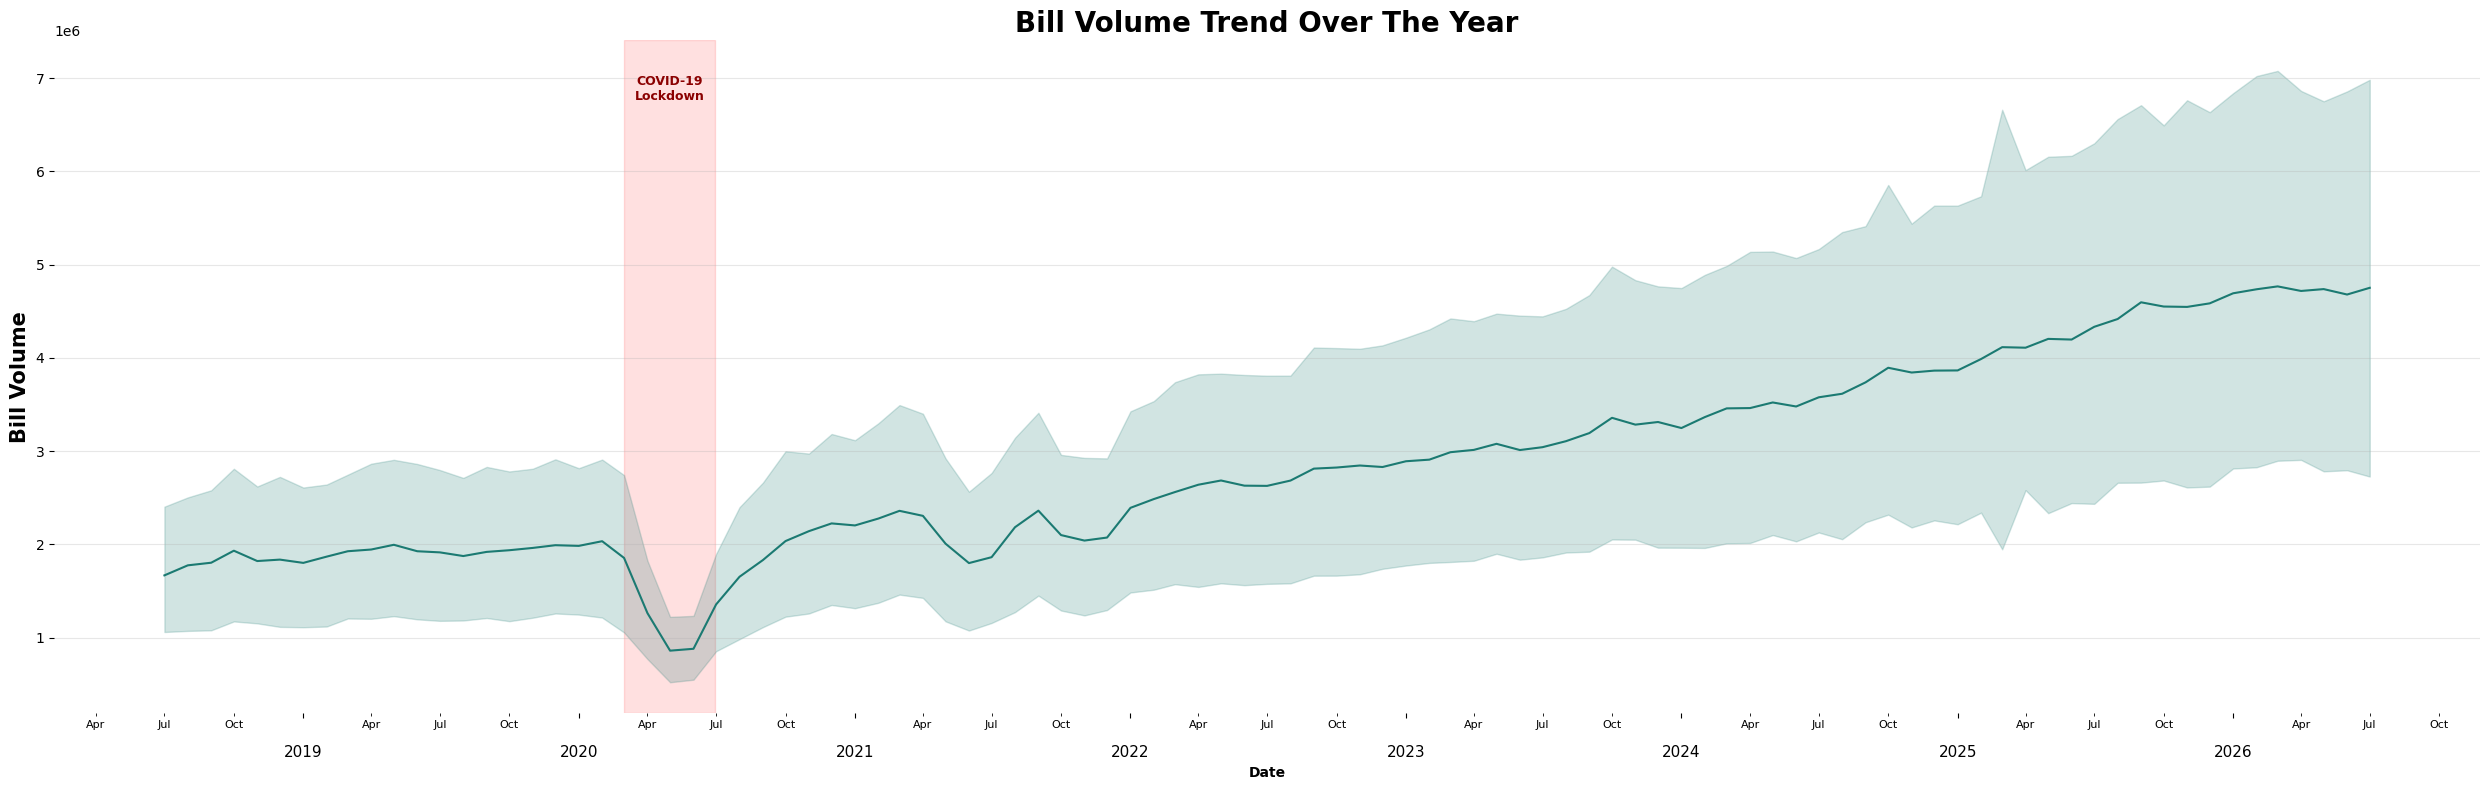

In [18]:
plot_bill_trend('avg_bill_3m',title="Bill Volume Trend Over The Year",filename="bill_volume_trend.png")

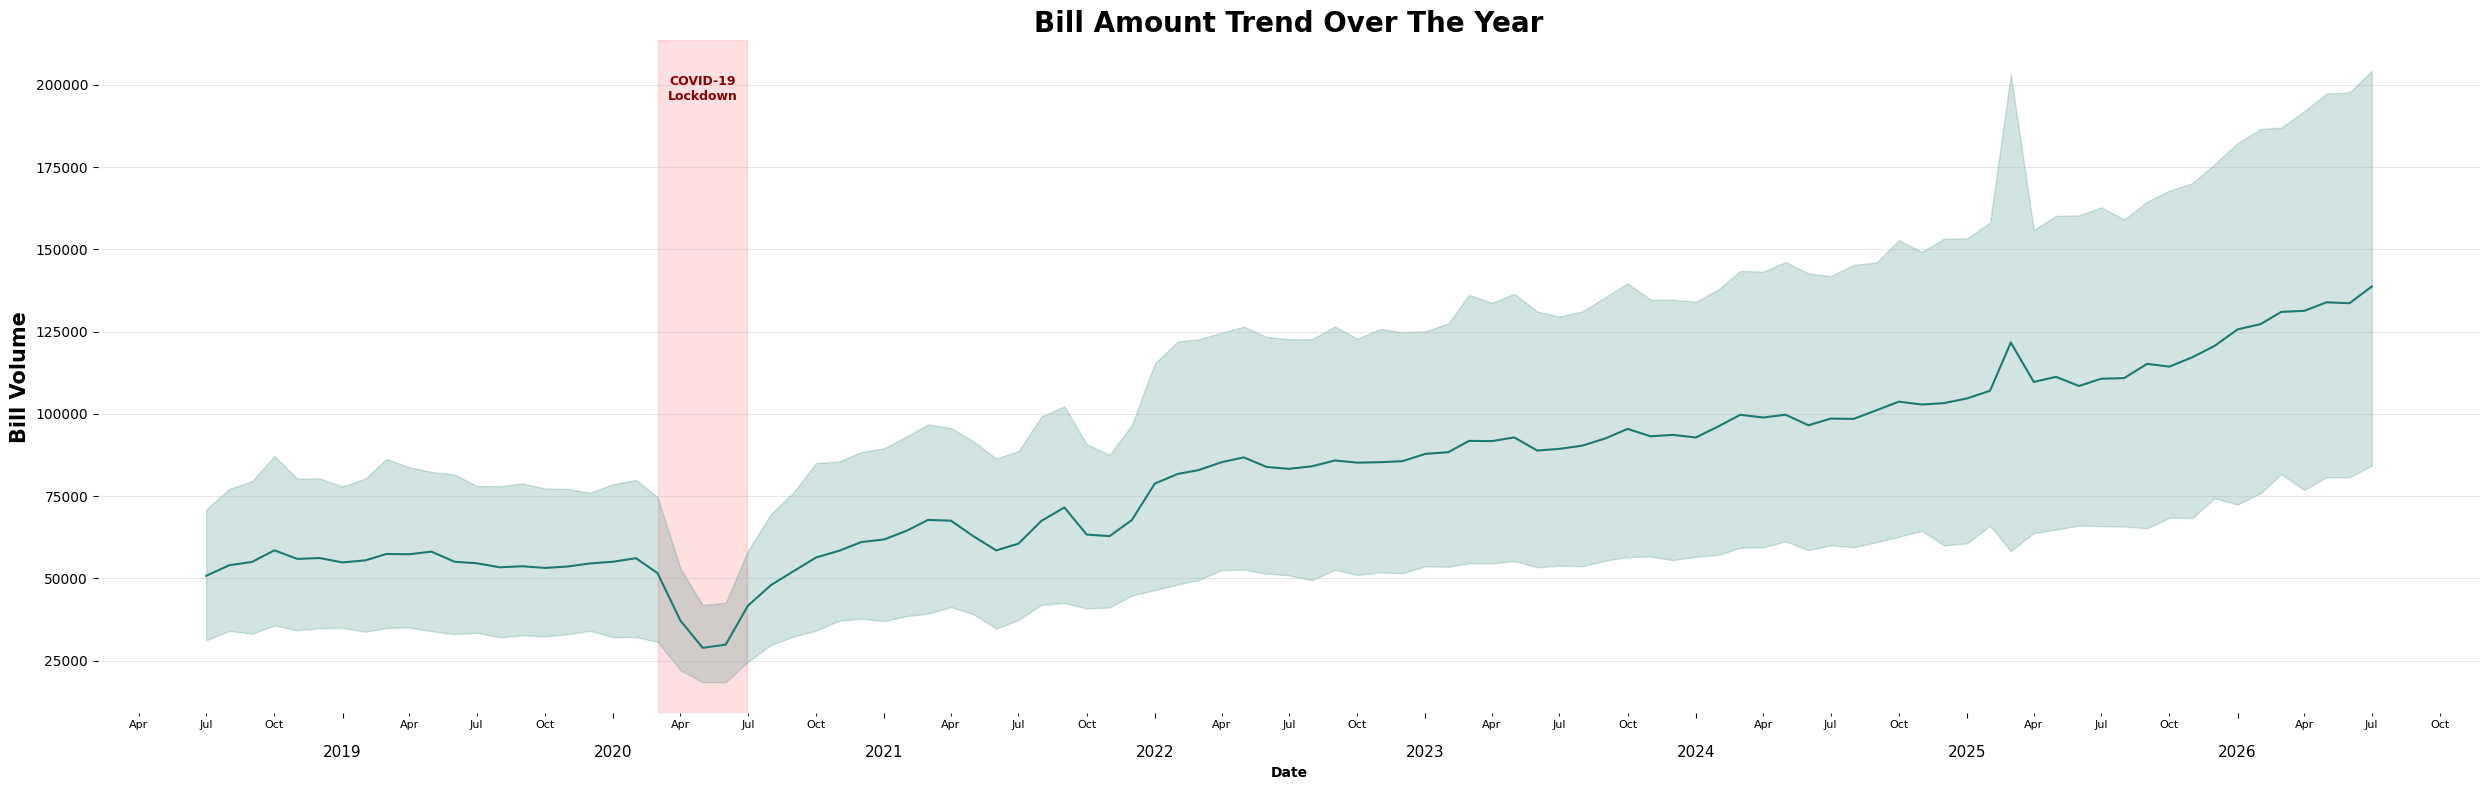

In [19]:
plot_bill_trend('avg_amount_3m',title="Bill Amount Trend Over The Year",filename="bill_amount_trend.png")

## Forecasting

In [20]:
data.head()

,state,date,bill_volume,bill_amount,avg_bill_3m,avg_amount_3m
0,andaman and nicobar,2018-07-01,7499.0,194.66,7499.0,194.66
1,andhra pradesh,2018-07-01,1931596.0,66363.08,1931596.0,66363.08
7,dadra and nagar haveli,2018-07-01,362641.0,16424.18,362641.0,16424.18
6,chhattisgarh,2018-07-01,610475.0,25003.50,610475.0,25003.50
2,arunachal pradesh,2018-07-01,19147.0,394.15,19147.0,394.15


In [21]:
print(f"Max Date: {data['date'].max()}")
print(f"Min Date: {data['date'].min()}")


Max Date: 2026-07-01 00:00:00
Min Date: 2018-07-01 00:00:00


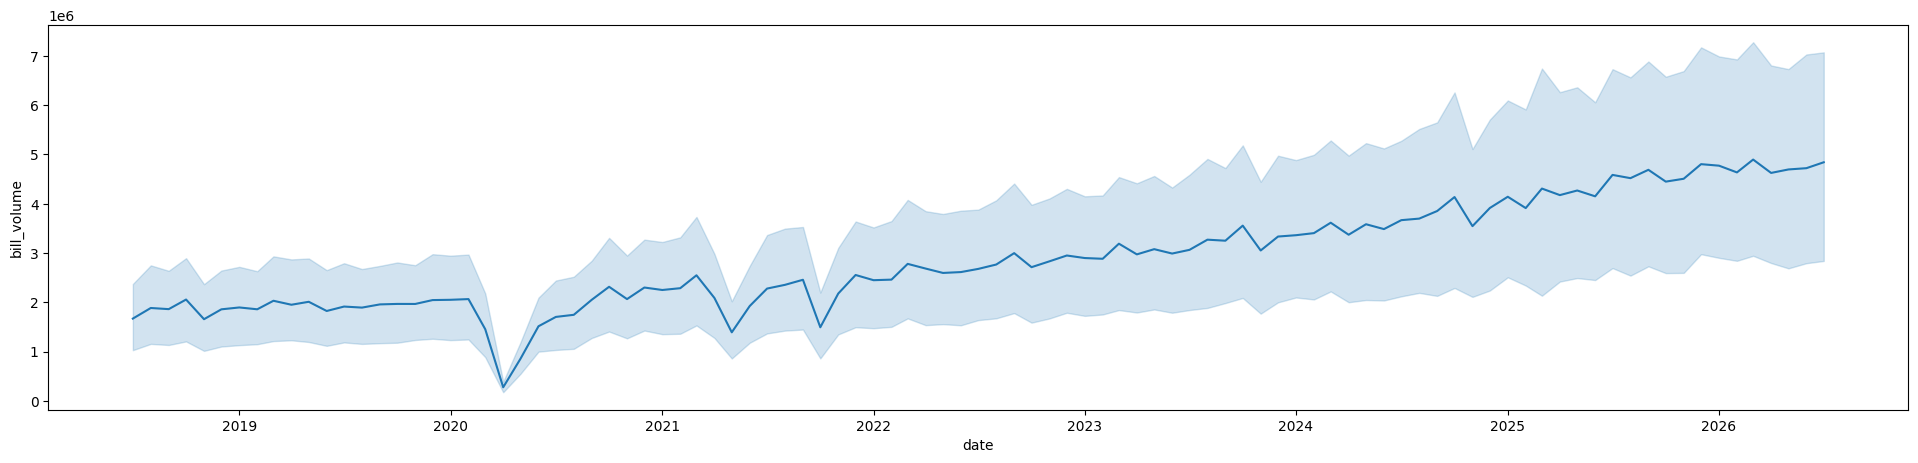

In [22]:
plt.figure(figsize=(24,5))
sns.lineplot(data=data, x='date',y='bill_volume')
plt.show()

In [23]:
volume_data = data[['state','date','bill_volume']]
volume_data.rename(columns={'date':'ds',"state":'unique_id'},inplace=True)

In [24]:
volume_grouped = volume_data.groupby('ds')['bill_volume'].sum().reset_index()

In [25]:
volume_grouped['unique_id']="india"

In [26]:
test = volume_grouped.tail(24)
train = volume_grouped.drop(test.index).reset_index(drop=True)

In [27]:
horizon = 24

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=6),
    SeasonalNaive(season_length=12),
    AutoARIMA(seasonal=False, alias="Arima"),
    AutoARIMA(season_length=12, alias="SArima")
]

forecast = StatsForecast(
    models=models,
    freq="MS"
)

# Model selection: cross-validate only on training data.
# The final 24 months remain untouched for final evaluation.
cv_df = forecast.cross_validation(
    df=train,
    h=6,
    target_col="bill_volume",
    n_windows=6,
    step_size=6
)

# Refit on training data and make the first 6-month test forecast
forecast.fit(df=train, target_col="bill_volume")
predictions = forecast.predict(h=horizon)

In [28]:
predictions

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive,Arima,SArima
0,india,2024-08-01,139309673.0,9.051359e+07,133770924.0,124263824.0,1.404556e+08,1.404556e+08
1,india,2024-09-01,139309673.0,9.051359e+07,133770924.0,123465315.0,1.382570e+08,1.382570e+08
2,india,2024-10-01,139309673.0,9.051359e+07,133770924.0,135089656.0,1.393575e+08,1.393575e+08
3,india,2024-11-01,139309673.0,9.051359e+07,133770924.0,115928451.0,1.404581e+08,1.404581e+08
4,india,2024-12-01,139309673.0,9.051359e+07,133770924.0,126678213.0,1.415587e+08,1.415587e+08
5,india,2025-01-01,139309673.0,9.051359e+07,133770924.0,127709244.0,1.426592e+08,1.426592e+08
6,india,2025-02-01,139309673.0,9.051359e+07,133770924.0,129310637.0,1.437598e+08,1.437598e+08
7,india,2025-03-01,139309673.0,9.051359e+07,133770924.0,137337705.0,1.448604e+08,1.448604e+08
8,india,2025-04-01,139309673.0,9.051359e+07,133770924.0,128078174.0,1.459609e+08,1.459609e+08
9,india,2025-05-01,139309673.0,9.051359e+07,133770924.0,136168098.0,1.470615e+08,1.470615e+08


In [29]:
test['month'] = pd.to_datetime(test['ds']).dt.to_period('M')
predictions['month'] = pd.to_datetime(predictions['ds']).dt.to_period('M')

evaluation_data = test.merge(
    predictions,
    on=['unique_id', 'month'],
    how='inner'
)

evaluation_data = evaluation_data.drop(columns=['ds_y'])
evaluation_data = evaluation_data.rename(columns={'ds_x': 'ds'})

In [30]:
evaluation_data

,ds,bill_volume,unique_id,month,Naive,HistoricAverage,WindowAverage,SeasonalNaive,Arima,SArima
0,2024-08-01,140510479.0,india,2024-08,139309673.0,9.051359e+07,133770924.0,124263824.0,1.404556e+08,1.404556e+08
1,2024-09-01,146360168.0,india,2024-09,139309673.0,9.051359e+07,133770924.0,123465315.0,1.382570e+08,1.382570e+08
2,2024-10-01,157134480.0,india,2024-10,139309673.0,9.051359e+07,133770924.0,135089656.0,1.393575e+08,1.393575e+08
3,2024-11-01,134692708.0,india,2024-11,139309673.0,9.051359e+07,133770924.0,115928451.0,1.404581e+08,1.404581e+08
4,2024-12-01,148689448.0,india,2024-12,139309673.0,9.051359e+07,133770924.0,126678213.0,1.415587e+08,1.415587e+08
5,2025-01-01,157358799.0,india,2025-01,139309673.0,9.051359e+07,133770924.0,127709244.0,1.426592e+08,1.426592e+08
6,2025-02-01,148624718.0,india,2025-02,139309673.0,9.051359e+07,133770924.0,129310637.0,1.437598e+08,1.437598e+08
7,2025-03-01,103372006.0,india,2025-03,139309673.0,9.051359e+07,133770924.0,137337705.0,1.448604e+08,1.448604e+08
8,2025-04-01,158629324.0,india,2025-04,139309673.0,9.051359e+07,133770924.0,128078174.0,1.459609e+08,1.459609e+08
9,2025-05-01,162174573.0,india,2025-05,139309673.0,9.051359e+07,133770924.0,136168098.0,1.470615e+08,1.470615e+08


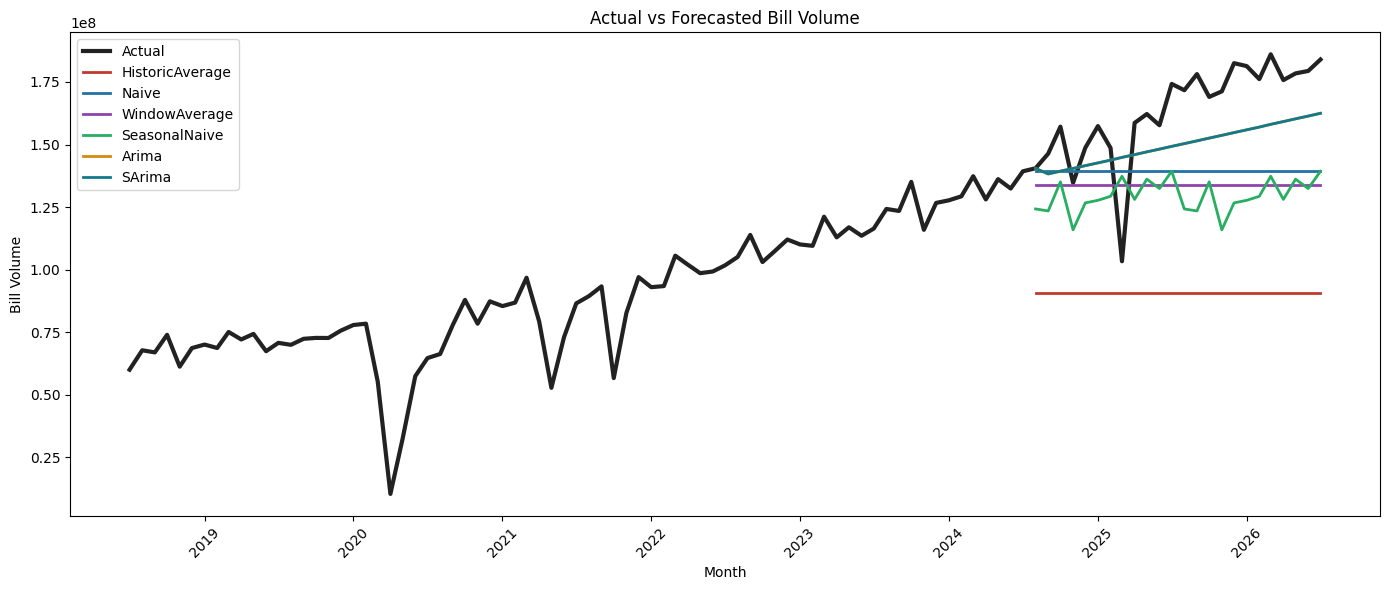

In [31]:
colors = [
    '#222222',  # Actual - dark grey
    '#C0392B',  # HistoricAverage - red
    '#2471A3',  # Naive - blue
    '#8E44AD',  # WindowAverage - purple
    '#27AE60',  # SeasonalNaive - green
    '#D68910',  # Arima - orange
    '#117A8B'   # SArima - teal
]

plt.figure(figsize=(14, 6))

plt.plot(
    volume_grouped['ds'],
    volume_grouped['bill_volume'],
    label='Actual',
    color=colors[0],
    linewidth=3
)

for model, color in zip(
    ['HistoricAverage', 'Naive', 'WindowAverage', 'SeasonalNaive', 'Arima', 'SArima'],
    colors[1:]
):
    plt.plot(
        evaluation_data['ds'],
        evaluation_data[model],
        label=model,
        color=color,
        linewidth=2
    )

plt.xlabel('Month')
plt.ylabel('Bill Volume')
plt.title('Actual vs Forecasted Bill Volume')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: >

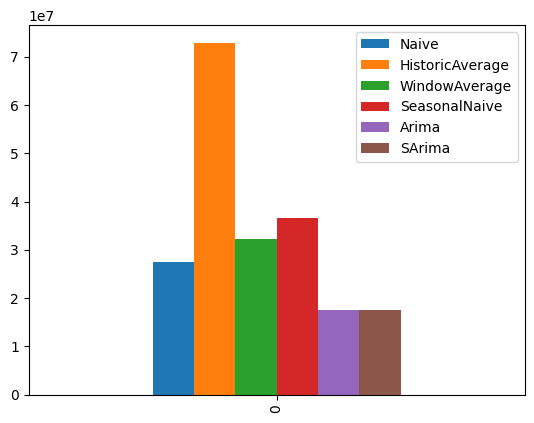

In [32]:
evalution = evaluate(
    evaluation_data.drop(columns = 'month'),
    metrics=[mae],
    target_col='bill_volume'
)
evalution.plot(kind='bar')